# MOGSage Grid-Search Results Explorer
Scans every completed run under `RESULTS_DIR`, aggregates the CSV outputs,
produces diagnostic plots, and highlights the top-5 configurations.

In [9]:
import os
import re
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import seaborn as sns
from palettable import wesanderson as wes
from pathlib import Path
from IPython.display import display, HTML

warnings.filterwarnings("ignore")

# ── USER CONFIG ──────────────────────────────────────────────────────────────
RESULTS_DIR = "./../../results/"   # root results folder
TOP_N       = 5                                    # highlight this many runs
RANK_BY     = "Exact Match"                           # column to rank runs by
HIGHER_IS_BETTER = True                         # set False if ranking by loss

# ── PLOT STYLE ────────────────────────────────────────────────────────────────
palette = wes.Darjeeling2_5.hex_colors
PALETTE_TOP  = palette[0]      # accent for top-N runs
PALETTE_REST = palette[1]      # colour for all other runs
BG           = "#FFFFFF"
PANEL_BG     = "#FFFFFF"
TEXT         = "#1a1d27"
GRID_COL     = palette[2]

plt.rcParams.update({
    "figure.facecolor":  BG,
    "axes.facecolor":    PANEL_BG,
    "axes.edgecolor":    GRID_COL,
    "axes.labelcolor":   TEXT,
    "axes.titlecolor":   TEXT,
    "xtick.color":       TEXT,
    "ytick.color":       TEXT,
    "text.color":        TEXT,
    "grid.color":        GRID_COL,
    "grid.linewidth":    0.5,
    "legend.facecolor":  PANEL_BG,
    "legend.edgecolor":  GRID_COL,
    "font.family":       "monospace",
    "figure.dpi":        120,
})

print("Config ready. Results dir:", RESULTS_DIR)

Config ready. Results dir: ./../../results/


## 1 · Collect results

In [10]:
def parse_run_tag(tag: str) -> dict:
    """Extract hyperparameters from a run-tag string."""
    patterns = {
        "decoder_dim":    r"dec(\d+)",
        "hidden_dim":     r"hid(\d+)",
        "emb_dim":        r"emb(\d+)",
        "enc_dims":       r"enc([\d\-]+)",
        "latent_dims":    r"lat([\d\-]+)",
        "alpha_contrast": r"_a([\d]+p[\d]+|[\d\.]+)",
        "temperature":    r"_t([\d]+p[\d]+|[\d\.]+)",
        "lr":             r"_lr([\d]+p[\d\-e]+|[\d\.e\-]+)",
        "weight_decay":   r"_wd([\d]+p[\d\-e]+|[\d\.e\-]+)",
        "dropout":        r"_do([\d]+p[\d]+|[\d\.]+)",
    }
    d = {"run_tag": tag}
    for key, pat in patterns.items():
        m = re.search(pat, tag)
        if m:
            raw = m.group(1).replace("p", ".")
            try:
                d[key] = float(raw) if "." in raw or "e" in raw else int(raw)
            except ValueError:
                d[key] = raw
    return d


overall_rows, perclass_rows = [], []
results_root = Path(RESULTS_DIR)

for run_dir in sorted(results_root.iterdir()):
    if not run_dir.is_dir():
        continue
    tag = run_dir.name

    ov_files = list(run_dir.glob("test_overall_*.csv"))
    pc_files = list(run_dir.glob("test_perclass_*.csv"))

    if not ov_files or not pc_files:
        continue                         # run incomplete – skip

    ov  = pd.read_csv(ov_files[0],  index_col=0)
    pc  = pd.read_csv(pc_files[0],  index_col=0)
    hp  = parse_run_tag(tag)

    # flatten overall metrics into one row
    row = {**hp}
    for col in ov.columns:
        row[col] = ov[col].iloc[0]
    overall_rows.append(row)

    # per-class: one row per class
    for cls in pc.index:
        pc_row = {**hp, "class": cls}
        pc_row.update(pc.loc[cls].to_dict())
        perclass_rows.append(pc_row)

overall_df  = pd.DataFrame(overall_rows)
perclass_df = pd.DataFrame(perclass_rows)

print(f"Runs found   : {len(overall_df)}")
print(f"Overall cols : {list(overall_df.columns)}")
print()
display(overall_df.head(3))

Runs found   : 768
Overall cols : ['run_tag', 'decoder_dim', 'hidden_dim', 'emb_dim', 'enc_dims', 'latent_dims', 'alpha_contrast', 'temperature', 'lr', 'weight_decay', 'dropout', 'Hamming Loss', 'Exact Match', 'Micro F1', 'Macro F1', 'Sample F1', 'Jaccard']



,run_tag,decoder_dim,hidden_dim,emb_dim,enc_dims,latent_dims,alpha_contrast,temperature,lr,weight_decay,dropout,Hamming Loss,Exact Match,Micro F1,Macro F1,Sample F1,Jaccard
0,dec128_hid128_emb32_enc128-128-128_lat32-32-32...,128,128,32,128-128-128,32-32-32,0.0,0.07,0.0001,0.0001,0.3,0.3736,0.1631,0.4147,0.4111,0.4089,0.3447
1,dec128_hid128_emb32_enc128-128-128_lat32-32-32...,128,128,32,128-128-128,32-32-32,0.0,0.07,0.0001,0.0001,0.5,0.3698,0.2062,0.4207,0.4096,0.4154,0.3599
2,dec128_hid128_emb32_enc128-128-128_lat32-32-32...,128,128,32,128-128-128,32-32-32,0.0,0.07,0.0005,0.0001,0.3,0.3026,0.2494,0.5112,0.4773,0.5172,0.4465


## 2 · Rank configurations

In [11]:
if RANK_BY not in overall_df.columns:
    print(f"[WARN] '{RANK_BY}' not found. Available: {list(overall_df.columns)}")
    print("       Falling back to first numeric column.")
    RANK_BY = overall_df.select_dtypes("number").columns[0]

overall_df = overall_df.sort_values(RANK_BY, ascending=not HIGHER_IS_BETTER).reset_index(drop=True)
overall_df["rank"] = overall_df.index + 1
overall_df["is_top"] = overall_df["rank"] <= TOP_N

top5 = overall_df[overall_df["is_top"]].copy()

print(f"\nRanking by '{RANK_BY}' ({'higher' if HIGHER_IS_BETTER else 'lower'} is better)")
print(f"\n{'─'*60}")
print(f"TOP-{TOP_N} CONFIGURATIONS")
print(f"{'─'*60}")

hp_cols = ["decoder_dim","hidden_dim","emb_dim","enc_dims","latent_dims",
           "alpha_contrast","temperature","lr","weight_decay","dropout"]
display_cols = [c for c in hp_cols if c in top5.columns] + [RANK_BY]
display(top5[display_cols].reset_index(drop=True))


Ranking by 'Exact Match' (higher is better)

────────────────────────────────────────────────────────────
TOP-5 CONFIGURATIONS
────────────────────────────────────────────────────────────


,decoder_dim,hidden_dim,emb_dim,enc_dims,latent_dims,alpha_contrast,temperature,lr,weight_decay,dropout,Exact Match
0,128,64,32,64-64-64,32-32-32,0.2,0.07,0.0005,0.0001,0.5,0.3909
1,64,128,64,64-64-64,64-64-64,0.2,0.07,0.0001,0.0001,0.5,0.3837
2,128,64,32,128-128-128,32-32-32,0.2,0.07,0.0005,0.0001,0.5,0.3813
3,64,128,32,64-64-64,32-32-32,0.2,0.07,0.0010,0.0001,0.5,0.3789
4,128,128,64,128-128-128,32-32-32,0.2,0.07,0.0005,0.0001,0.5,0.3765


## 3 · Leaderboard

In [12]:
metric_cols = [c for c in overall_df.columns
               if c not in ["run_tag","rank","is_top"] + hp_cols
               and overall_df[c].dtype in [float, "float64"]]

leaderboard = overall_df[["rank","run_tag"] + metric_cols].head(20)

def style_leaderboard(df):
    """Highlight top-N rows in the leaderboard."""
    styles = []
    for i in range(len(df)):
        if df.iloc[i]["rank"] <= TOP_N:
            styles.append([f"background-color: #2a1a1a; color: {PALETTE_TOP}; font-weight:bold"] * len(df.columns))
        else:
            styles.append([""] * len(df.columns))
    return pd.DataFrame(styles, columns=df.columns, index=df.index)

styled = (leaderboard.style
          .apply(style_leaderboard, axis=None)
          .format({c: "{:.4f}" for c in metric_cols})
          .set_caption(f"Top-20 runs ranked by {RANK_BY}"))
display(styled)

,rank,run_tag,Hamming Loss,Exact Match,Micro F1,Macro F1,Sample F1,Jaccard
0,1,dec128_hid64_emb32_enc64-64-64_lat32-32-32_a0p2_t0p07_lr0p0005_wd0p0001_do0p5,0.2801,0.3909,0.4739,0.3722,0.4864,0.4612
1,2,dec64_hid128_emb64_enc64-64-64_lat64-64-64_a0p2_t0p07_lr0p0001_wd0p0001_do0p5,0.2878,0.3837,0.4718,0.3959,0.4860,0.4596
2,3,dec128_hid64_emb32_enc128-128-128_lat32-32-32_a0p2_t0p07_lr0p0005_wd0p0001_do0p5,0.2916,0.3813,0.4676,0.3885,0.4735,0.4494
3,4,dec64_hid128_emb32_enc64-64-64_lat32-32-32_a0p2_t0p07_lr0p001_wd0p0001_do0p5,0.3017,0.3789,0.4840,0.4245,0.4949,0.4648
4,5,dec128_hid128_emb64_enc128-128-128_lat32-32-32_a0p2_t0p07_lr0p0005_wd0p0001_do0p5,0.2998,0.3765,0.4752,0.4027,0.4984,0.4652
5,6,dec128_hid128_emb32_enc64-64-64_lat32-32-32_a0p2_t0p07_lr0p0005_wd0p0001_do0p5,0.3050,0.3765,0.4619,0.3896,0.4802,0.4512
6,7,dec64_hid128_emb64_enc64-64-64_lat64-64-64_a0p5_t0p07_lr0p001_wd0p0001_do0p5,0.3031,0.3741,0.4811,0.4214,0.4893,0.4578
7,8,dec128_hid64_emb32_enc128-128-128_lat32-32-32_a0p5_t0p07_lr0p001_wd0p0001_do0p5,0.3098,0.3741,0.4696,0.4130,0.4839,0.4534
8,9,dec64_hid128_emb32_enc128-128-128_lat32-32-32_a0p2_t0p07_lr0p001_wd0p0001_do0p5,0.3060,0.3741,0.4788,0.4243,0.4942,0.4622
9,10,dec64_hid128_emb64_enc128-128-128_lat32-32-32_a0p5_t0p07_lr0p0001_wd0p0001_do0p5,0.2969,0.3741,0.4641,0.3773,0.4834,0.4549


## 4 · Metric distributions across all runs

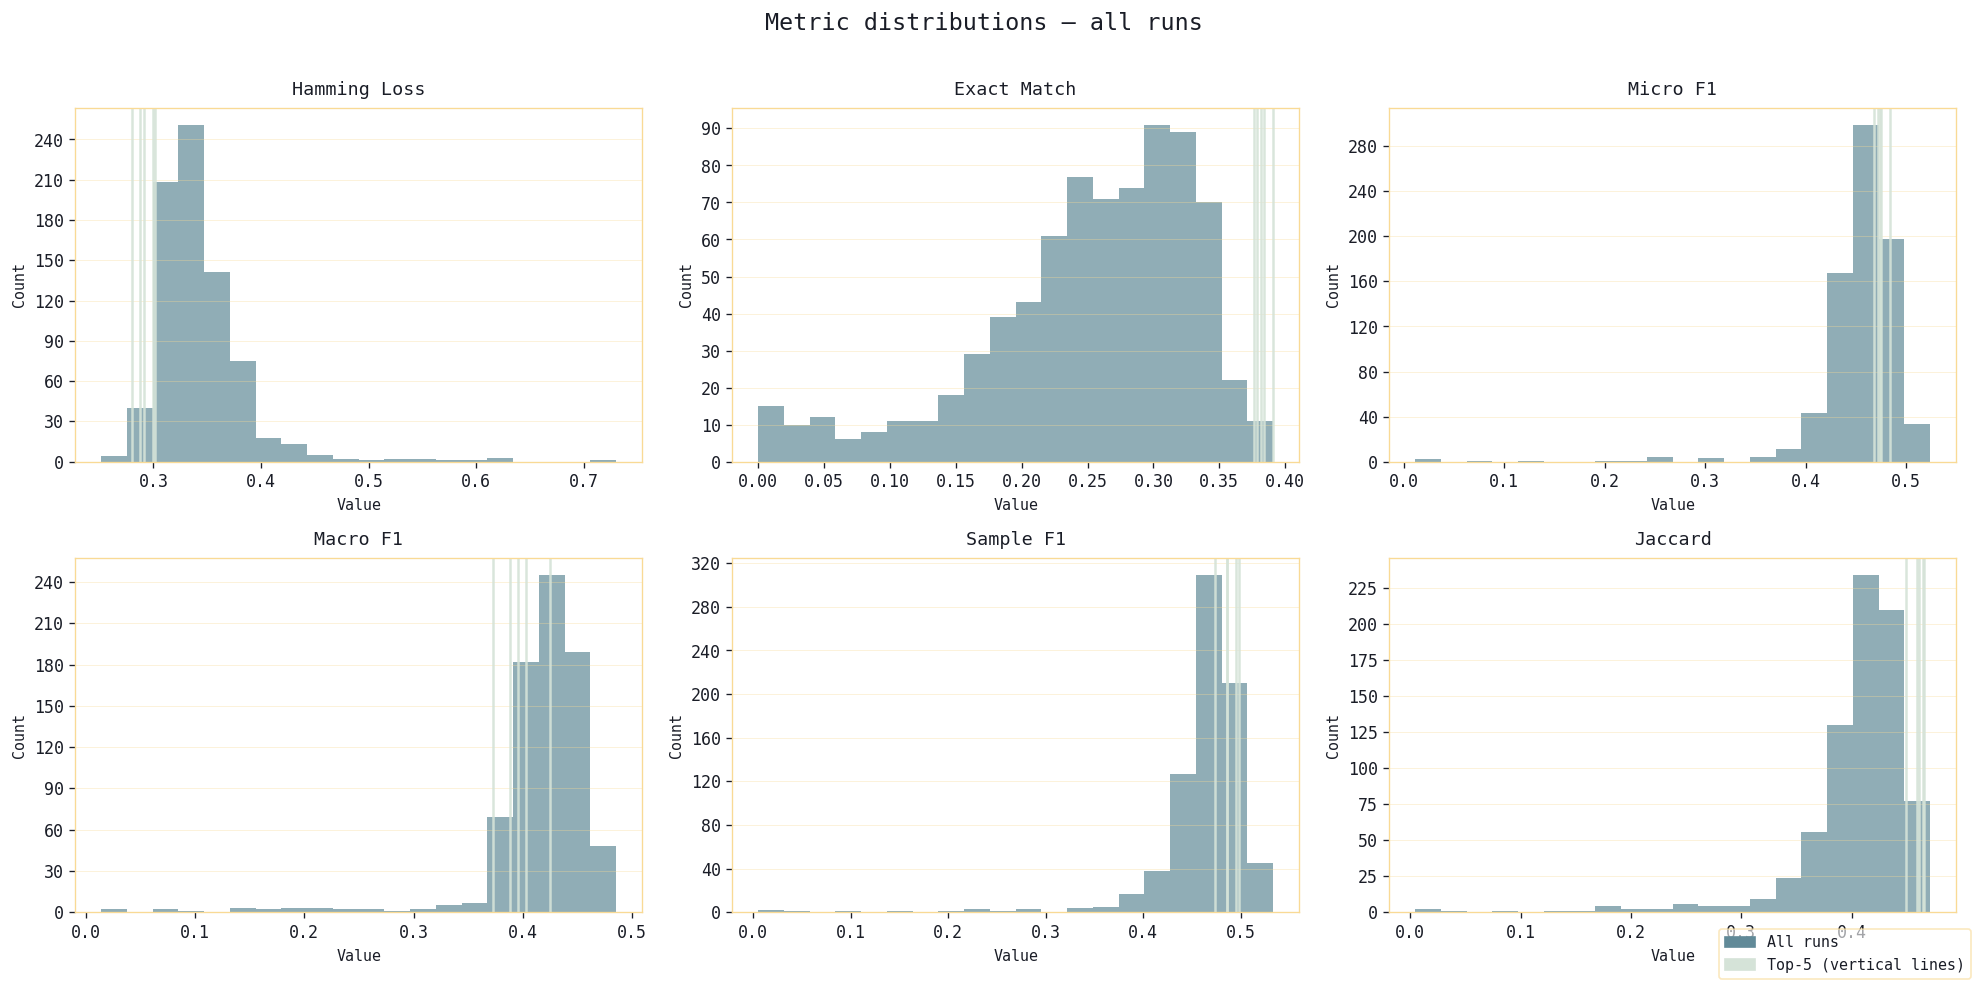

In [13]:
plot_metrics = [c for c in metric_cols if c in overall_df.columns][:6]
ncols = 3
nrows = int(np.ceil(len(plot_metrics) / ncols))

fig, axes = plt.subplots(nrows, ncols,
                         figsize=(5.5 * ncols, 4 * nrows),
                         facecolor=BG)
axes = axes.flatten()

for ax, metric in zip(axes, plot_metrics):
    vals_all = overall_df[metric].dropna()
    vals_top = top5[metric].dropna()

    ax.hist(vals_all, bins=20, color=PALETTE_REST, alpha=0.7, label="All runs", edgecolor="none")
    for v in vals_top:
        ax.axvline(v, color=PALETTE_TOP, linewidth=1.5, alpha=0.9)

    ax.set_title(metric, fontsize=11, pad=8)
    ax.set_xlabel("Value", fontsize=9)
    ax.set_ylabel("Count",  fontsize=9)
    ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
    ax.grid(axis="y", alpha=0.4)

# hide unused axes
for ax in axes[len(plot_metrics):]:
    ax.set_visible(False)

top_patch  = mpatches.Patch(color=PALETTE_TOP,  label=f"Top-{TOP_N} (vertical lines)")
rest_patch = mpatches.Patch(color=PALETTE_REST, label="All runs")
fig.legend(handles=[rest_patch, top_patch],
           loc="lower right", fontsize=9, framealpha=0.6)

fig.suptitle("Metric distributions — all runs", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 5 · Top-5 configuration comparison

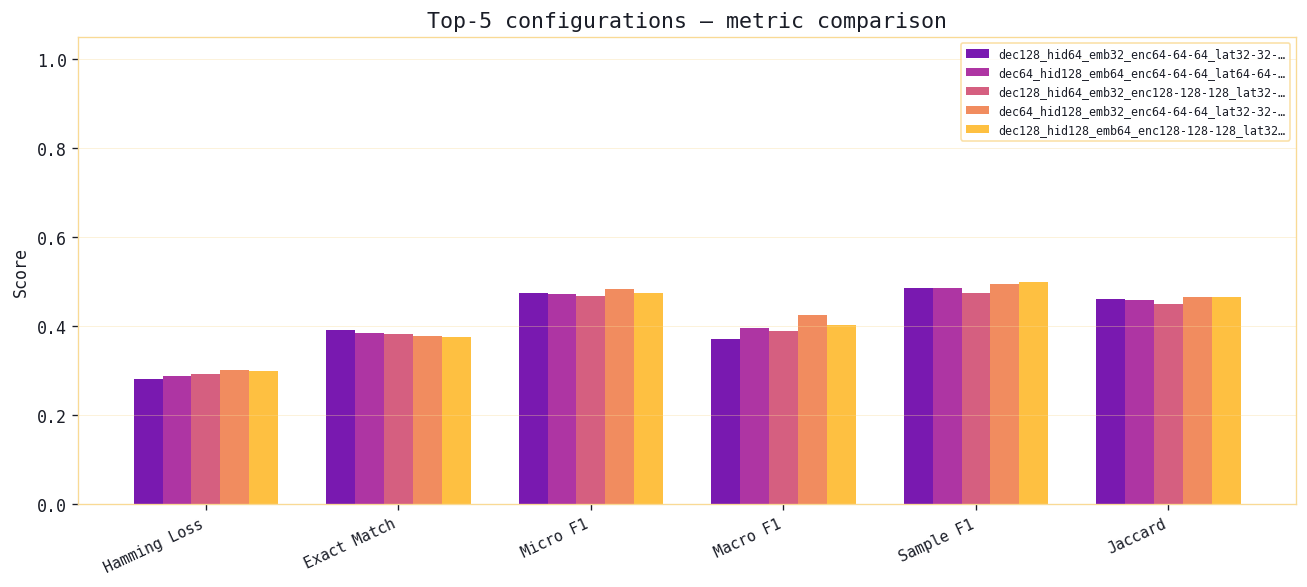

In [14]:
top5_metrics = top5[["run_tag"] + plot_metrics].set_index("run_tag")

fig, ax = plt.subplots(figsize=(11, 5), facecolor=BG)

x      = np.arange(len(plot_metrics))
width  = 0.15
colors = plt.cm.plasma(np.linspace(0.2, 0.85, len(top5_metrics)))

for i, (run, row) in enumerate(top5_metrics.iterrows()):
    # truncate long run tags for the legend
    label = run[:40] + "…" if len(run) > 40 else run
    ax.bar(x + i * width, row[plot_metrics].values,
           width, label=label, color=colors[i], alpha=0.9)

ax.set_xticks(x + width * (len(top5_metrics) - 1) / 2)
ax.set_xticklabels(plot_metrics, rotation=25, ha="right", fontsize=9)
ax.set_ylabel("Score")
ax.set_title(f"Top-{TOP_N} configurations — metric comparison", fontsize=13)
ax.legend(fontsize=7, loc="upper right", ncol=1)
ax.grid(axis="y", alpha=0.4)
ax.set_ylim(0, 1.05)

plt.tight_layout()
plt.show()

## 6 · Hyperparameter sensitivity

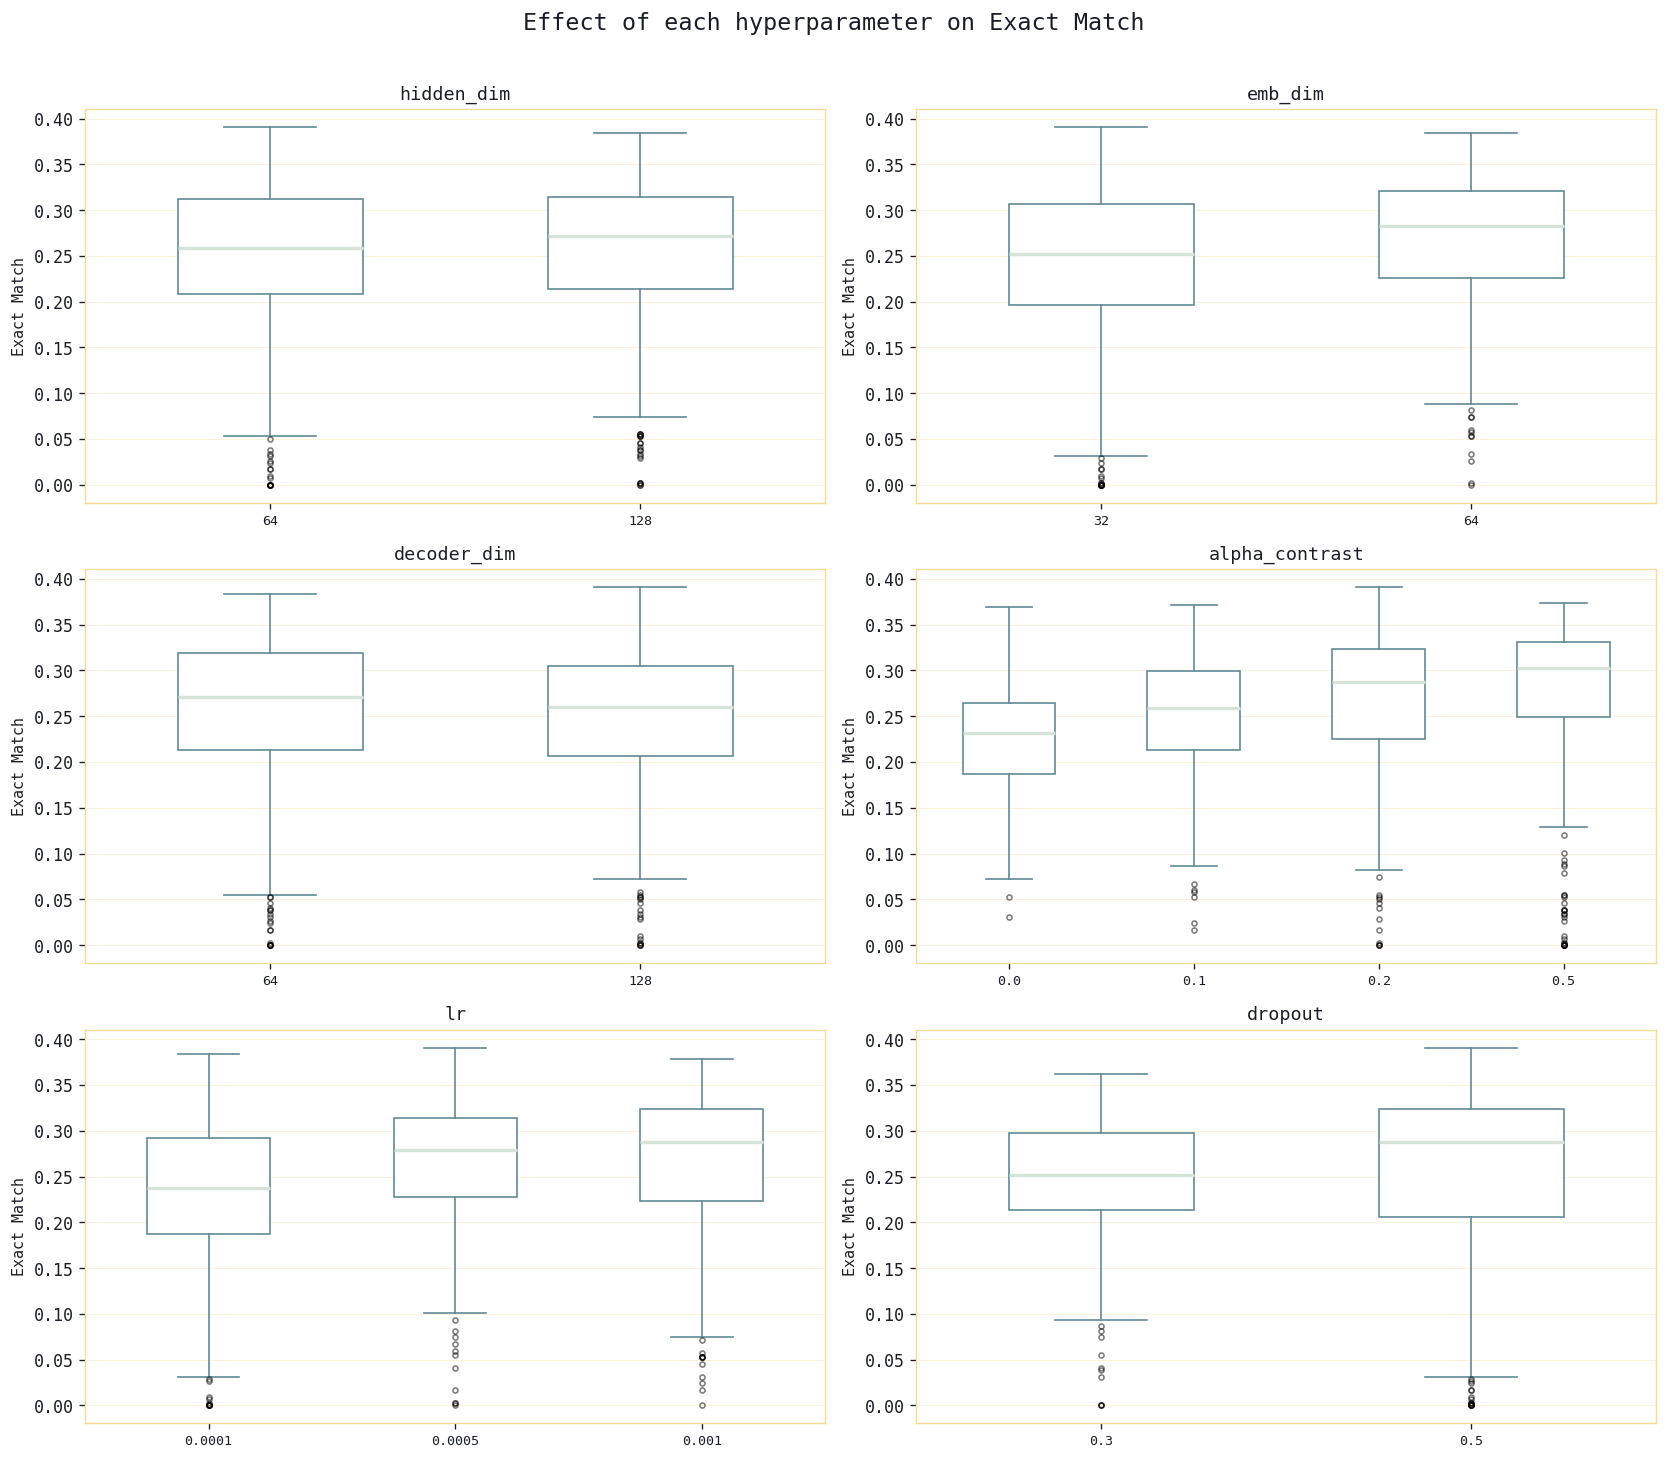

In [15]:
sweep_hps = [c for c in ["hidden_dim","emb_dim","decoder_dim",
                          "alpha_contrast","temperature","lr",
                          "weight_decay","dropout"]
             if c in overall_df.columns and overall_df[c].nunique() > 1]

ncols = 2
nrows = int(np.ceil(len(sweep_hps) / ncols))

fig, axes = plt.subplots(nrows, ncols,
                         figsize=(7 * ncols, 4 * nrows),
                         facecolor=BG)
axes = axes.flatten()

for ax, hp in zip(axes, sweep_hps):
    grp = overall_df.groupby(hp)[RANK_BY].apply(list)
    positions = range(len(grp))
    labels    = [str(k) for k in grp.index]

    bp = ax.boxplot(grp.values, positions=list(positions),
                    patch_artist=True, widths=0.5,
                    medianprops=dict(color=PALETTE_TOP, linewidth=2),
                    whiskerprops=dict(color=PALETTE_REST),
                    capprops=dict(color=PALETTE_REST),
                    flierprops=dict(marker="o", color=PALETTE_REST,
                                   markersize=3, alpha=0.5))
    for patch in bp["boxes"]:
        patch.set_facecolor(PANEL_BG)
        patch.set_edgecolor(PALETTE_REST)

    ax.set_xticks(list(positions))
    ax.set_xticklabels(labels, fontsize=8)
    ax.set_title(hp, fontsize=11)
    ax.set_ylabel(RANK_BY, fontsize=9)
    ax.grid(axis="y", alpha=0.4)

for ax in axes[len(sweep_hps):]:
    ax.set_visible(False)

fig.suptitle(f"Effect of each hyperparameter on {RANK_BY}", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 7 · Per-class F1 heatmap (top-10 runs)

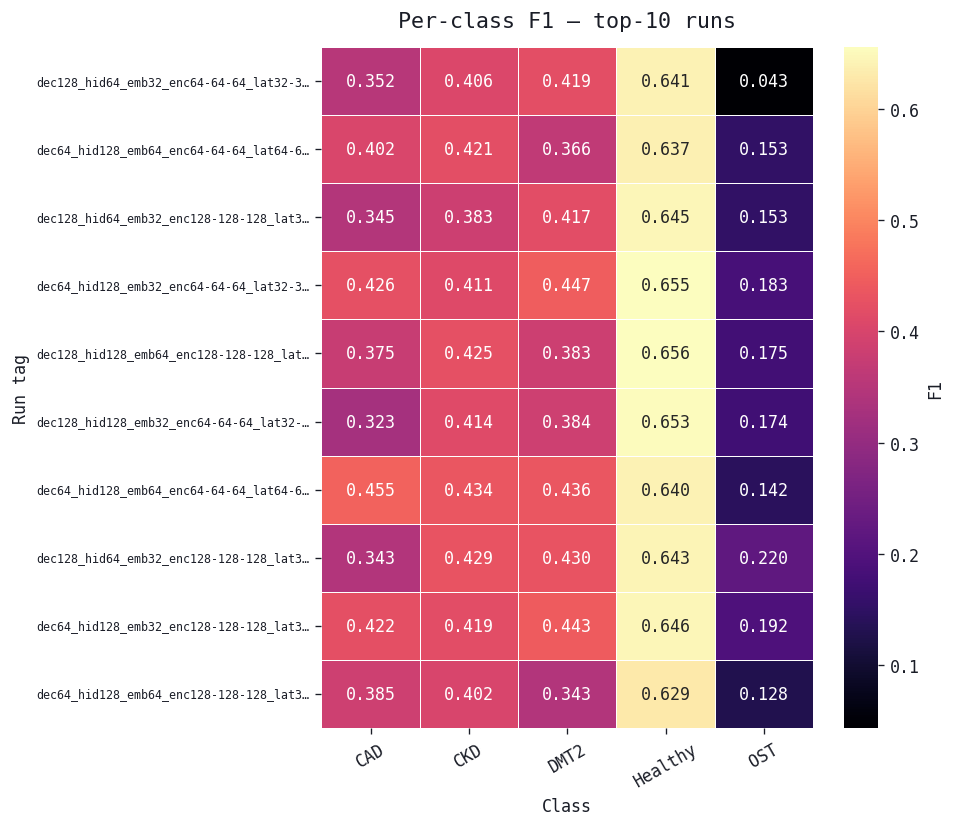

In [16]:
top10_tags = overall_df.head(10)["run_tag"].tolist()

pc_f1 = (perclass_df[perclass_df["run_tag"].isin(top10_tags)]
         [["run_tag","class","f1_micro"]]
         .pivot(index="run_tag", columns="class", values="f1_micro")
         .reindex(top10_tags))

# shorten row labels
pc_f1.index = [t[:38] + "…" if len(t) > 38 else t for t in pc_f1.index]

fig, ax = plt.subplots(figsize=(max(8, len(pc_f1.columns) * 1.5),
                                max(5, len(pc_f1) * 0.6 + 1)),
                       facecolor=BG)

sns.heatmap(pc_f1.astype(float),
            annot=True, fmt=".3f",
            cmap="magma",
            linewidths=0.5, linecolor=BG,
            ax=ax,
            cbar_kws={"label": "F1"})

ax.set_title("Per-class F1 — top-10 runs", fontsize=13, pad=12)
ax.set_xlabel("Class",   fontsize=10)
ax.set_ylabel("Run tag", fontsize=10)
ax.tick_params(axis="x", rotation=30)
ax.tick_params(axis="y", rotation=0, labelsize=7)

plt.tight_layout()
plt.show()

## 8 · Hyperparameter–metric correlation

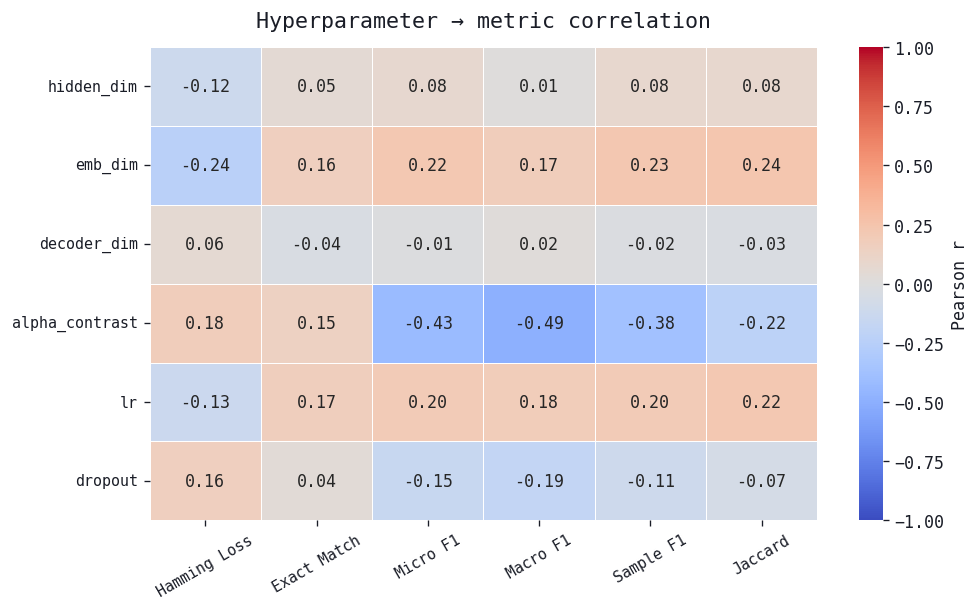

In [17]:
num_hp_cols = [c for c in sweep_hps if overall_df[c].dtype in [float, int, "float64", "int64"]]
corr_cols   = num_hp_cols + plot_metrics
corr_df     = overall_df[corr_cols].dropna().corr()

# show only HP → metric block
corr_block = corr_df.loc[num_hp_cols, plot_metrics]

fig, ax = plt.subplots(figsize=(max(6, len(plot_metrics) * 1.4),
                                max(4, len(num_hp_cols) * 0.7 + 1)),
                       facecolor=BG)

sns.heatmap(corr_block,
            annot=True, fmt=".2f",
            cmap="coolwarm", center=0, vmin=-1, vmax=1,
            linewidths=0.5, linecolor=BG,
            ax=ax,
            cbar_kws={"label": "Pearson r"})

ax.set_title("Hyperparameter → metric correlation", fontsize=13, pad=12)
ax.tick_params(axis="x", rotation=30, labelsize=9)
ax.tick_params(axis="y", rotation=0,  labelsize=9)

plt.tight_layout()
plt.show()

## 9 · Best configuration summary

In [18]:
best = overall_df.iloc[0]

lines = [
    "<div style='background:#1a1d27;border:1px solid #e84545;border-radius:8px;"
    "padding:20px 28px;font-family:monospace;max-width:720px'>",
    f"<h3 style='color:#e84545;margin-top:0'>🏆 Rank 1 — Best Configuration</h3>",
    f"<p style='color:#6f7f96;font-size:0.85em;margin:0 0 14px'>{best['run_tag']}</p>",
    "<table style='width:100%;border-collapse:collapse'>",
]

hp_display = {c: best[c] for c in hp_cols if c in best.index}
met_display = {c: best[c] for c in metric_cols if c in best.index}

lines.append("<tr><td colspan=4 style='color:#e84545;padding:6px 0;font-weight:bold;"
             "border-bottom:1px solid #2a2d3a'>Hyperparameters</td></tr>")
items = list(hp_display.items())
for i in range(0, len(items), 2):
    row_html = "<tr>"
    for k, v in items[i:i+2]:
        fmt_v = f"{v:.5g}" if isinstance(v, float) else str(v)
        row_html += (f"<td style='color:#6f7f96;padding:3px 8px'>{k}</td>"
                     f"<td style='color:#aeb8c9;padding:3px 16px 3px 4px'>{fmt_v}</td>")
    row_html += "</tr>"
    lines.append(row_html)

lines.append("<tr><td colspan=4 style='color:#e84545;padding:10px 0 6px;font-weight:bold;"
             "border-bottom:1px solid #2a2d3a'>Test Metrics</td></tr>")
met_items = list(met_display.items())
for i in range(0, len(met_items), 2):
    row_html = "<tr>"
    for k, v in met_items[i:i+2]:
        fmt_v = f"{v:.4f}" if isinstance(v, float) else str(v)
        row_html += (f"<td style='color:#6f7f96;padding:3px 8px'>{k}</td>"
                     f"<td style='color:#aeb8c9;padding:3px 16px 3px 4px'>{fmt_v}</td>")
    row_html += "</tr>"
    lines.append(row_html)

lines += ["</table>", "</div>"]
display(HTML("\n".join(lines)))
